# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo! Tu proyecto es excepcional y has logrado cubrir los objetivos del mismo. Abajo he dejado mis comentarios y unas pequeñas recomendaciones para que tomes en cuenta en un futuro y te hagan ¡un máster en Data!

¡Felicidades!    

</div>



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression    
from sklearn.ensemble import RandomForestClassifier     
from lightgbm import LGBMClassifier                     
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
pd.set_option('display.max_columns', None)

try:
    df_contract = pd.read_csv('/datasets/final_provider/contract.csv')
    df_personal = pd.read_csv('/datasets/final_provider/personal.csv')
    df_internet = pd.read_csv('/datasets/final_provider/internet.csv')
    df_phone = pd.read_csv('/datasets/final_provider/phone.csv')
    print("¡Todos los archivos cargados correctamente!")
except Exception as e:
    print(f"Error al cargar archivos: {e}")

¡Todos los archivos cargados correctamente!


In [3]:
datasets = {
    "Contratos": df_contract,
    "Personal": df_personal,
    "Internet": df_internet,
    "Telefonía": df_phone
}

for name, df in datasets.items():
    print(f"--- Dataset: {name} ---")
    print(df.info())
    print(f"Valores duplicados: {df.duplicated().sum()}")
    print(f"Muestra inicial:")
    display(df.head(3))
    print("\n")


--- Dataset: Contratos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
None
Valores duplicados: 0
Muestra inicial:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15




--- Dataset: Personal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
None
Valores duplicados: 0
Muestra inicial:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No




--- Dataset: Internet ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
None
Valores duplicados: 0
Muestra inicial:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No




--- Dataset: Telefonía ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
None
Valores duplicados: 0
Muestra inicial:


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No


In [4]:
df_telecom_full = df_contract.merge(df_personal, on='customerID', how='left')

df_telecom_full = df_telecom_full.merge(df_internet, on='customerID', how='left')
df_telecom_full = df_telecom_full.merge(df_phone, on='customerID', how='left')

print(f"Forma final del dataset unido: {df_telecom_full.shape}")

Forma final del dataset unido: (7043, 20)


In [5]:
df_telecom_full['target'] = (df_telecom_full['EndDate'] != 'No').astype(int)

fecha_corte = pd.to_datetime('2020-02-01')

df_telecom_full['BeginDate'] = pd.to_datetime(df_telecom_full['BeginDate'])

df_telecom_full['temp_end_date'] = df_telecom_full['EndDate'].replace('No', '2020-02-01')
df_telecom_full['temp_end_date'] = pd.to_datetime(df_telecom_full['temp_end_date'])

df_telecom_full['tenure_days'] = (df_telecom_full['temp_end_date'] - df_telecom_full['BeginDate']).dt.days

df_telecom_full = df_telecom_full.drop('temp_end_date', axis=1)

df_telecom_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   object        
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

In [6]:
df_telecom_full['TotalCharges'] = pd.to_numeric(df_telecom_full['TotalCharges'], errors='coerce')

# 2. Investigar los NaN en TotalCharges (suelen ser clientes que empezaron el mismo día de la corte)
# Los llenamos con 0 o con el valor de MonthlyCharges
df_telecom_full['TotalCharges'] = df_telecom_full['TotalCharges'].fillna(0)

# 3. Llenar nulos en servicios adicionales
# Si el cliente no estaba en la tabla de internet o teléfono, significa que "No" tiene el servicio
servicios_adicionales = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for servicio in servicios_adicionales:
    df_telecom_full[servicio] = df_telecom_full[servicio].fillna('No')

df_telecom_full.info()
print("Limpieza completada.")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

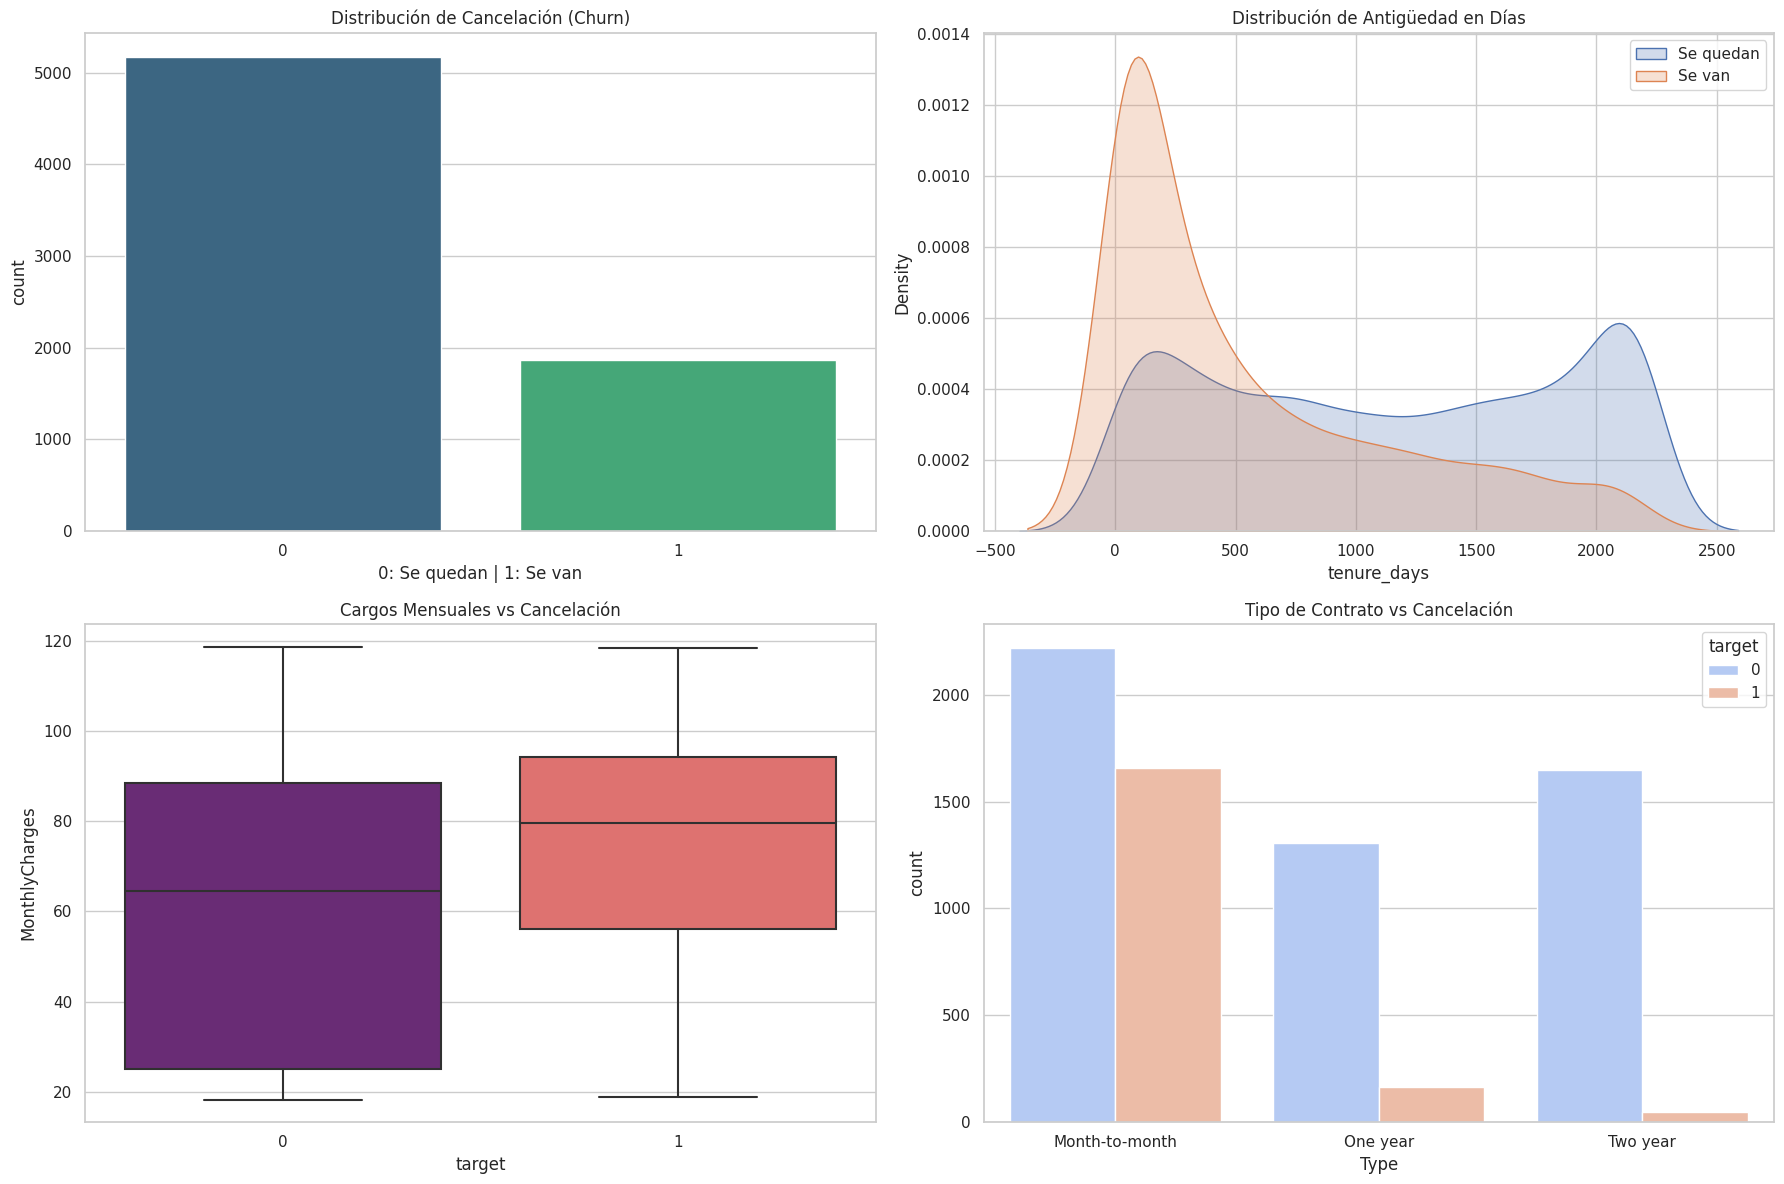

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las gráficas
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

# 1. Distribución del Target (¿Cuántos se van vs cuántos se quedan?)
plt.subplot(2, 2, 1)
sns.countplot(x='target', data=df_telecom_full, palette='viridis')
plt.title('Distribución de Cancelación (Churn)')
plt.xlabel('0: Se quedan | 1: Se van')

# 2. Antigüedad (tenure_days) vs Target
plt.subplot(2, 2, 2)
sns.kdeplot(df_telecom_full[df_telecom_full['target'] == 0]['tenure_days'], label='Se quedan', shade=True)
sns.kdeplot(df_telecom_full[df_telecom_full['target'] == 1]['tenure_days'], label='Se van', shade=True)
plt.title('Distribución de Antigüedad en Días')
plt.legend()

# 3. Cargos Mensuales vs Target
plt.subplot(2, 2, 3)
sns.boxplot(x='target', y='MonthlyCharges', data=df_telecom_full, palette='magma')
plt.title('Cargos Mensuales vs Cancelación')

# 4. Tipo de Contrato vs Target
plt.subplot(2, 2, 4)
sns.countplot(x='Type', hue='target', data=df_telecom_full, palette='coolwarm')
plt.title('Tipo de Contrato vs Cancelación')

plt.tight_layout()
plt.show()

In [8]:
# 1. Definimos qué columnas eliminar (IDs, fechas y el target)
# Eliminamos 'customerID', 'BeginDate' y 'EndDate' porque ya extrajimos la información en 'tenure_days'
columnas_a_eliminar = ['customerID', 'BeginDate', 'EndDate', 'target']

# 2. Creamos el conjunto de características (features) y el objetivo (target)
features = df_telecom_full.drop(columnas_a_eliminar, axis=1)
target = df_telecom_full['target']

# 3. Codificación de variables categóricas (One-Hot Encoding)
# drop_first=True evita la redundancia de datos (trampa de la variable ficticia)
features_encoded = pd.get_dummies(features, drop_first=True)

print(f"Columnas originales: {features.shape[1]}")
print(f"Columnas después de codificación: {features_encoded.shape[1]}")

Columnas originales: 18
Columnas después de codificación: 22


In [9]:
features_train, features_test, target_train, target_test = train_test_split(
    features_encoded, 
    target, 
    test_size=0.20, 
    random_state=12345,
    stratify=target # Mantiene la proporción de churn en ambos sets
)

print(f"Tamaño de entrenamiento: {features_train.shape[0]} muestras")
print(f"Tamaño de prueba: {features_test.shape[0]} muestras")

Tamaño de entrenamiento: 5634 muestras
Tamaño de prueba: 1409 muestras


In [10]:
features_train = features_train.copy()
features_test = features_test.copy()

num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_days']
scaler = StandardScaler()

# Ajustamos el escalador solo con los datos de entrenamiento
scaler.fit(features_train[num_cols])

# Transformamos ambos conjuntos
features_train[num_cols] = scaler.transform(features_train[num_cols])
features_test[num_cols] = scaler.transform(features_test[num_cols])

print("Escalamiento completado con éxito.")

Escalamiento completado con éxito.


In [11]:
lr_model = LogisticRegression(random_state=12345, solver='liblinear')

# 2. Entrenar el modelo
lr_model.fit(features_train, target_train)

# 3. Obtener probabilidades (necesarias para el AUC-ROC)
# Tomamos la columna [:, 1] que es la probabilidad de que el cliente se vaya (Clase 1)
probabilities_lr = lr_model.predict_proba(features_test)[:, 1]

# 4. Obtener predicciones finales (para Exactitud)
predictions_lr = lr_model.predict(features_test)

# 5. Calcular métricas
auc_lr = roc_auc_score(target_test, probabilities_lr)
accuracy_lr = accuracy_score(target_test, predictions_lr)

print(f"--- Modelo 1: Regresión Logística ---")
print(f"AUC-ROC: {auc_lr:.4f}")
print(f"Exactitud (Accuracy): {accuracy_lr:.4f}")

--- Modelo 1: Regresión Logística ---
AUC-ROC: 0.8372
Exactitud (Accuracy): 0.7991


In [12]:
rf_base = RandomForestClassifier(random_state=12345)

# 2. Definir los parámetros a probar (Grid)
# n_estimators: cantidad de árboles
# max_depth: profundidad de los árboles (qué tanto "aprende")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Configurar la búsqueda (GridSearchCV)
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring='roc_auc', # Optimizamos para la métrica del proyecto
    cv=3,              # Validación cruzada de 3 pliegues
    verbose=1,
    n_jobs=-1          # Usar todos los procesadores para ir más rápido
)

# 4. Entrenar
grid_rf.fit(features_train, target_train)

# 5. Obtener el mejor modelo y sus resultados
best_rf = grid_rf.best_estimator_

# Predicciones en el set de prueba
probabilities_rf = best_rf.predict_proba(features_test)[:, 1]
predictions_rf = best_rf.predict(features_test)

print(f"--- Modelo 2: Random Forest ---")
print(f"Mejores parámetros: {grid_rf.best_params_}")
print(f"AUC-ROC en entrenamiento (mejor score CV): {grid_rf.best_score_:.4f}")
print(f"AUC-ROC final en Test: {roc_auc_score(target_test, probabilities_rf):.4f}")
print(f"Exactitud (Accuracy): {accuracy_score(target_test, predictions_rf):.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
--- Modelo 2: Random Forest ---
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}
AUC-ROC en entrenamiento (mejor score CV): 0.8588
AUC-ROC final en Test: 0.8506
Exactitud (Accuracy): 0.8155


In [13]:
lgb_base = LGBMClassifier(random_state=12345, importance_type='gain')

# 2. Definir los parámetros a optimizar
# learning_rate: qué tan rápido "aprende" el modelo (valores pequeños suelen ser mejores)
# num_leaves: complejidad de los árboles
param_grid_lgb = {
    'n_estimators': [200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [21, 31, 41],
    'max_depth': [3, 5, 7]
}

# 3. Configurar la búsqueda (GridSearchCV)
grid_lgb = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid_lgb,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# 4. Entrenar el modelo
grid_lgb.fit(features_train, target_train)

# 5. Obtener el mejor modelo y evaluar
best_lgb = grid_lgb.best_estimator_
probabilities_lgb = best_lgb.predict_proba(features_test)[:, 1]
predictions_lgb = best_lgb.predict(features_test)

print(f"--- Modelo 3: LightGBM ---")
print(f"Mejores parámetros: {grid_lgb.best_params_}")
print(f"AUC-ROC en entrenamiento (mejor CV): {grid_lgb.best_score_:.4f}")
print(f"AUC-ROC final en Test: {roc_auc_score(target_test, probabilities_lgb):.4f}")
print(f"Exactitud (Accuracy): {accuracy_score(target_test, predictions_lgb):.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
--- Modelo 3: LightGBM ---
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'num_leaves': 21}
AUC-ROC en entrenamiento (mejor CV): 0.8954
AUC-ROC final en Test: 0.9001
Exactitud (Accuracy): 0.8630


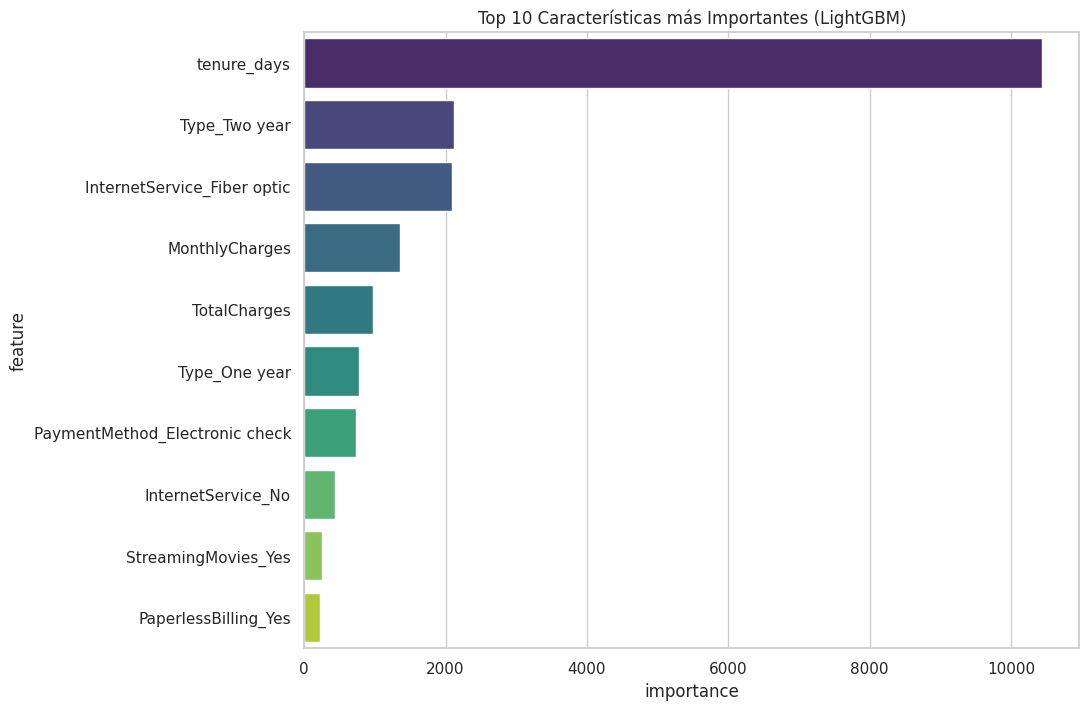

In [14]:
importances = pd.DataFrame({
    'feature': features_test.columns,
    'importance': best_lgb.feature_importances_
}).sort_values(by='importance', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importances.head(10), palette='viridis')
plt.title('Top 10 Características más Importantes (LightGBM)')
plt.show()



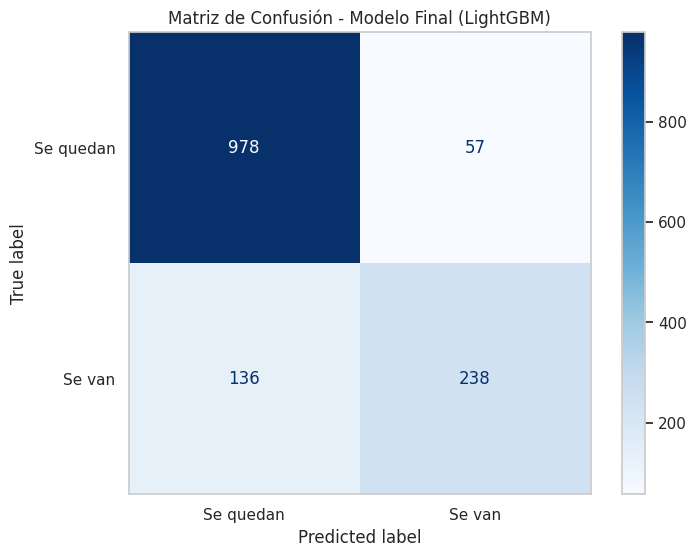

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions_lgb = best_lgb.predict(features_test)

cm = confusion_matrix(target_test, predictions_lgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se quedan', 'Se van'])


fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo Final (LightGBM)')
plt.grid(False) 
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Buen trabajo Luis Fernando, tu notebook implementa un flujo completo desde la carga y unión de fuentes hasta modelos con ajuste de hiperparámetros y evaluación (Logistic, RandomForest y LightGBM) ✅. Se aprecian pasos de limpieza, codificación, escalado y evaluación con AUC y matriz de confusión. 

Sin embargo, pude notar que hay áreas técnicas y de presentación que conviene reforzar (por ejemplo: falta un modelo base/simple de referencia, no se usó un split temporal para validar la naturaleza cronológica y no se muestra calibración de umbrales ni consideración explícita de costos/metricas de negocio) ⚠️. 

En la conclusión incluyo acciones concretas para mejorar. 🚀
</div>

### Conclusiones y recomendaciones
- Nivel general de cumplimiento: intermedio. Tienes un pipeline reproducible y técnicas apropiadas de modelado (preprocesamiento, codificación, escalado, búsqueda de hiperparámetros y análisis de importancia) ✅

- Principales fortalezas:
  - Flujo claro y reproducible: carga, unión de tablas, creación de target y variable tenure, y manejo de nulos. ✅  
  - Buena experimentación de modelos y optimización de hiperparámetros (GridSearchCV) con métricas adecuadas (ROC-AUC). ✅  
  - Visualizaciones relevantes (distribución de target, tenure, boxplot de cargos, importancia de features y matriz de confusión) que apoyan el análisis. 📊

- Áreas de oportunidad y mejora:
  - Toma en cuenta que faltó incluir un modelo base/simple (por ejemplo DummyClassifier) para comparar ganancias reales del modelado. También sería bueno reportar métricas adicionales relevantes al negocio (precision/recall/F1, curva PR) y analizar umbrales según costo de false positives/negatives. ⚠️  
  - Asegúrate de probar una partición temporal (time-based split) en lugar de un split aleatorio cuando la variable objetivo depende del tiempo; esto da una evaluación más realista (chequea esto cuando tengas tiempo, es un buen tutorial, Medium es una fuente confiable de aprendizaje https://medium.com/@mouadenna/time-series-splitting-techniques-ensuring-accurate-model-validation-5a3146db3088) 🔁  
  - **ESTO ELEVARIA TU PROYECTO A OTRO NIVEL** Reforzar la interpretación de resultados desde el negocio: explicar implicaciones operativas de predecir churn, y documentar decisiones de limpieza (p. ej. por qué rellenar TotalCharges con 0). Además convendría explorar balanceo de clases o técnicas de muestreo si es necesario (QUE QUIZA AHORA NO LO NECESITAS, PERO EN PROYECTOS REALES NO PODRIAMOS ASUMIR ESTO TAN EXPLICITAMENTE) 💡 CREEME, POR EXPERIENCIA, NUNCA VA A HACER FALTA AQUEL STAKEHOLDER 👨🏻‍💼 QUE VA A CUESTIONAR PASO A PASO LO QUE HAS HECHO, NUESTRA MEJOR DEFENSA ES EL ANALISIS, LAS PRUEBAS Y EL STORYTELLING.

Bienvenido al mundo de los Data Scientists reales 🦄 y con esos ajustes (sugerencias) el trabajo sube a un nivel más sólido y aplicable a negocio. Que seguramente va a ser un gap que vas a ir cerrando poco a poco. ¡Vas muy bien, sigue puliendo esos detalles para dejar el entregable listo para producción! 🚀